# Proyecto de Vision por Computador Semana 2

## GRUPO 6 - PARALELO B
- CHILUISA GALLARDO ROBINSON
- LANCHIMBA CAIZA NATALY FERNANDA
- CHOEZ ARTEAGA TEOFILO MANUEL

## Actividad individual calificable:

En esta actividad, llevaremos a cabo una serie de pruebas para evaluar la capacidad de nuestro modelo de clasificación de imágenes. El objetivo es identificar correctamente si una imagen contiene el rostro de un estudiante específico o si pertenece a un fondo. Para ello, hemos definido dos etiquetas principales:

##### **Label 1:** `Nombre del estudiante`  
##### **Label 2:** `Fondo` (imagenes que no contengan el rostro del estudiante)

#### **Pruebas:**

Las pruebas se realizarán con diferentes tipos de imágenes de entrada para verificar la precisión del modelo en escenarios no vistos durante el entrenamiento:

1. **Input image:** Foto del estudiante que no se encuentre en la carpeta de entrenamiento (tómate una foto el día de la presentación usando tu webcam).
**Required output label:** `Nombre del estudiante`

2. **Input image:** Fondo que no se encuentre en la carpeta de entrenamiento (el estudiante que presente antes de ti te dará la palabra de búsqueda, puedes descargarla de Google Images).  
**Required output label:** `Fondo`
3. **Input image:** Foto de un rostro diferente al rostro del estudiante que no se encuentre en las carpetas de entrenamiento (el estudiante que presente antes de ti te dará un nombre de una celebridad que se parezca a ti, puedes descargarla de Google Images).  
**Required output label:** `Fondo`

##### **Hyperparameter testing (Opcional):**

Además, puedes explorar el impacto de varios hiperparámetros en el rendimiento del modelo. Los hiperparámetros a ajustar incluyen:

-Aumento de imágenes en la base de datos  
-Cambio de función de pérdida (loss)  
-Cambio en el optimizador (optimizer)  
-Cambio en el número de épocas de entrenamiento (epochs)  
-Cambio en el número de tamaño de lote (batch_size)

Estas pruebas y ajustes te permitirán optimizar el modelo para obtener la mejor precisión posible en la clasificación de imágenes.

##### **Presentación de resultados**

Los estudiantes presentarán sus resultados en clase usando una app de `streamlit`. La calificación dependerá del éxito de las 3 pruebas.

In [54]:
import importlib
import subprocess
import sys

# Lista de paquetes requeridos
paquetes = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "keras": "keras",
    "tensorflow": "tensorflow",
    "ipykernel": "ipykernel"
}

faltantes = []
for modulo, paquete in paquetes.items():
    try:
        importlib.import_module(modulo)
    except ImportError:
        faltantes.append(paquete)

if faltantes:
    print(f"Instalando paquetes faltantes: {faltantes}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
else:
    print("Todas las librerías requeridas ya están instaladas.")


Todas las librerías requeridas ya están instaladas.


**Importamos las librerias necesarias**

In [55]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Cargamos las imágenes:

In [70]:
def load_images(folder):
    # Inicializamos las listas para almacenar las imágenes y las etiquetas
    images = []
    labels = []

    # Obtener el nombre de la carpeta
    folder_name = os.path.basename(folder)

    # Iteramos sobre cada archivo en la carpeta especificada
    for filename in os.listdir(folder):
        # Leemos la imagen utilizando OpenCV
        img = cv2.imread(os.path.join(folder, filename))

        # Si la imagen se ha leído correctamente
        if img is not None:
            # Redimensionamos la imagen a 224x224 píxeles para que coincida con la dimensión de entrada de VGG-16
            img = cv2.resize(img, (224, 224))
            # Añadimos la imagen a la lista de imágenes
            images.append(img)

            # Asignamos la etiqueta correspondiente según la carpeta
            if folder_name == 'Nataly':
                labels.append(1) # Etiqueta 1 para estudiante
            elif folder_name == 'Fondo':
                labels.append(0) # Etiqueta 0 para fondos

    return images, labels


# Cargamos las imágenes y etiquetas de perros desde el directorio especificado
# La función load_images se encarga de leer las imágenes y sus etiquetas correspondientes
nataly_images, nataly_labels = load_images(r'Bases\Nataly')

# Cargamos las imágenes y etiquetas de gatos desde el directorio especificado
# Similar a la carga de imágenes de perros, esta función lee las imágenes de gatos y sus etiquetas
fondo_images, fondo_labels = load_images(r'Bases\Fondo')

# Combinamos los arrays de perros y gatos
images = np.array(nataly_images + fondo_images)
labels = np.array(nataly_labels + fondo_labels)
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [71]:
## Normalizar las imagenes antes del modelamiento
images = preprocess_input(images)

In [72]:
## Dividir la data en train y test

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2,
    random_state=42,
    stratify=labels)

In [73]:
## aqui se crean variaciones artificiales de las imagenes en entrenamiento para evitar el sobreajuste

datagen = ImageDataGenerator(
    rotation_range=20, # Se permite rotar la imagen ya que las caras no siempre estan rectas
    zoom_range=0.2, # Hace zoom de la cara para identificar la cara a diferentes distancias
    horizontal_flip=True, # Invierte la imagen de la cara como un espejo
    brightness_range=[0.7,1.3], #Se varia la iluminación 
    width_shift_range=0.1, # Mueve la imagen de manera horizontal ya que no siemor estan centradas
    height_shift_range=0.1 # Muevve la imagen de manera vertical
)

In [74]:
## Se construye el modelo con depp learning

# Definimos el callback de EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Se utiliza un modelo con pesos ya entrenado
baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))

# Congelar las capas
for layer in baseModel.layers:
    layer.trainable = False

# Modelo final donde se extraen las caracteristicas
model = Sequential([
    baseModel,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'), ## Aprende patrones de la data de entrenamiento
    Dropout(0.5), ## Se apagan aleatoriamente neuronas en el proceso
    Dense(1, activation='sigmoid') ## Capa final con prob entre 0 y 1
])

# Se compila el modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Enternar el modelo**

In [75]:
model.fit(
    datagen.flow(X_train, y_train, batch_size=20),
    validation_data=(X_test, y_test),
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 873ms/step - accuracy: 0.7233 - loss: 1.0463 - val_accuracy: 0.9808 - val_loss: 0.0660
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 882ms/step - accuracy: 0.9078 - loss: 0.3616 - val_accuracy: 0.9615 - val_loss: 0.1889
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 990ms/step - accuracy: 0.9563 - loss: 0.1690 - val_accuracy: 0.9808 - val_loss: 0.0302
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 959ms/step - accuracy: 0.9563 - loss: 0.1271 - val_accuracy: 0.9615 - val_loss: 0.0477
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9709 - loss: 0.0808 - val_accuracy: 0.9808 - val_loss: 0.0320
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 933ms/step - accuracy: 0.9757 - loss: 0.0598 - val_accuracy: 0.9808 - val_loss: 0.0470
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 916ms/step - accuracy: 0.9854 - loss: 0.0345 - val_accuracy: 0.9808 - val_loss: 0.0660
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 905ms/step - accuracy: 0.9903 - loss: 0.0294 - val_accurac

In [76]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 735ms/step - accuracy: 0.9808 - loss: 0.1259
Loss: 0.12589529156684875
Accuracy: 0.9807692170143127


In [77]:
# Exportamos en modelo en un formato .h5
model.save('modelo_clasificacion_rostros_fondo_op_3.h5')

In [78]:
# Cargamos el modelo desde un archivo formato .h5
from keras.models import load_model
model = load_model('modelo_clasificacion_rostros_fondo_op_3.h5')

In [79]:
## Función para probar nuevas imagenes

def predecir_imagen(ruta):

    # Leemos la imagen
    img = cv2.imread(ruta)

    # Verificamos que la imagen exista
    if img is None:
        print(f"No se pudo leer la imagen: {ruta}")
        return

    # Convertimos a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar imagen
    plt.imshow(img_rgb)

    # Preprocesamiento para el modelo
    img_model = cv2.resize(img_rgb,(224,224))
    img_model = np.array(img_model)
    img_model = preprocess_input(img_model)
    img_model = np.expand_dims(img_model, axis=0)

    # Predicción
    pred = model.predict(img_model, verbose=0)

    # Clasificación
    if pred[0][0] > 0.5:
        plt.title('Nataly')
    else:
        plt.title('Fondo')

    plt.axis('off')
    plt.show()

**Foto del estudiante que no se encuentra en entrenamiento**

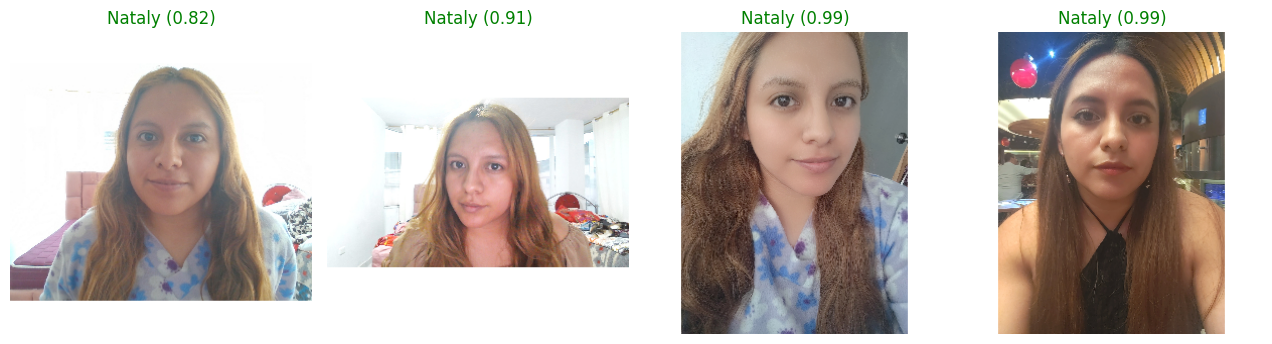

In [83]:
def resize_con_padding(img, size=300):

    h, w = img.shape[:2]

    escala = size / max(h, w)

    new_w = int(w * escala)
    new_h = int(h * escala)

    img_resized = cv2.resize(img, (new_w, new_h))

    canvas = np.ones((size, size, 3), dtype=np.uint8) * 255

    x_offset = (size - new_w) // 2
    y_offset = (size - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img_resized

    return canvas

rutas = [
r'Bases/nataly0.jpg',
r'Bases/nataly1.jpg',
r'Bases/nataly3.jpg',
r'Bases/nataly4.jpg',
]

plt.figure(figsize=(16,8))

for i, ruta in enumerate(rutas):

    img = cv2.imread(ruta)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------- PREDICCIÓN ----------
    img_model = cv2.resize(img_rgb,(224,224))
    img_model = preprocess_input(img_model)
    img_model = np.expand_dims(img_model, axis=0)

    pred = model.predict(img_model, verbose=0)

    prob = pred[0][0]

    if prob > 0.5:
        titulo = f"Nataly ({prob:.2f})"
        color = "green"
    else:
        titulo = f"Fondo ({prob:.2f})"
        color = "red"

    # ---------- SOLO PARA VISUALIZAR ----------
    img_show = resize_con_padding(img_rgb, 300)

    plt.subplot(2,5,i+1)
    plt.imshow(img_show)
    plt.title(titulo, color=color, fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Fondo que no se encuentra en entrenamiento**

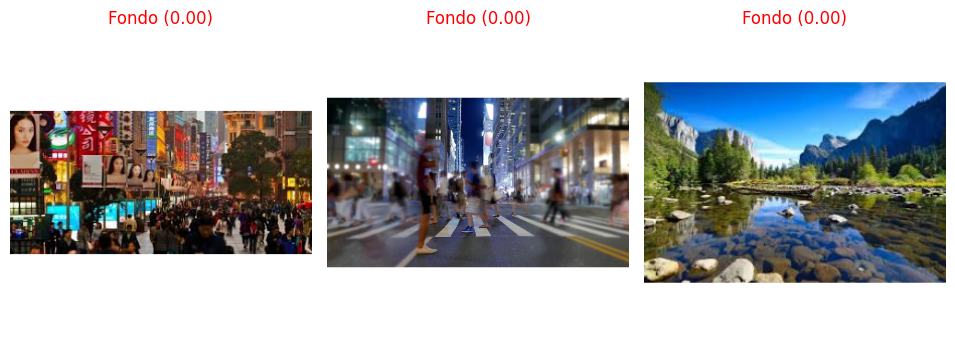

In [81]:
rutas = [
r'Bases/nueva.jpeg',
r'Bases/nueva2.jpg',
r'Bases/nueva3.jpeg'
]

plt.figure(figsize=(16,8))

for i, ruta in enumerate(rutas):

    img = cv2.imread(ruta)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------- PREDICCIÓN ----------
    img_model = cv2.resize(img_rgb,(224,224))
    img_model = preprocess_input(img_model)
    img_model = np.expand_dims(img_model, axis=0)

    pred = model.predict(img_model, verbose=0)

    prob = pred[0][0]

    if prob > 0.5:
        titulo = f"Nataly ({prob:.2f})"
        color = "green"
    else:
        titulo = f"Fondo ({prob:.2f})"
        color = "red"

    # ---------- SOLO PARA VISUALIZAR ----------
    img_show = resize_con_padding(img_rgb, 300)

    plt.subplot(2,5,i+1)
    plt.imshow(img_show)
    plt.title(titulo, color=color, fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Fotos con rostros diferentes**

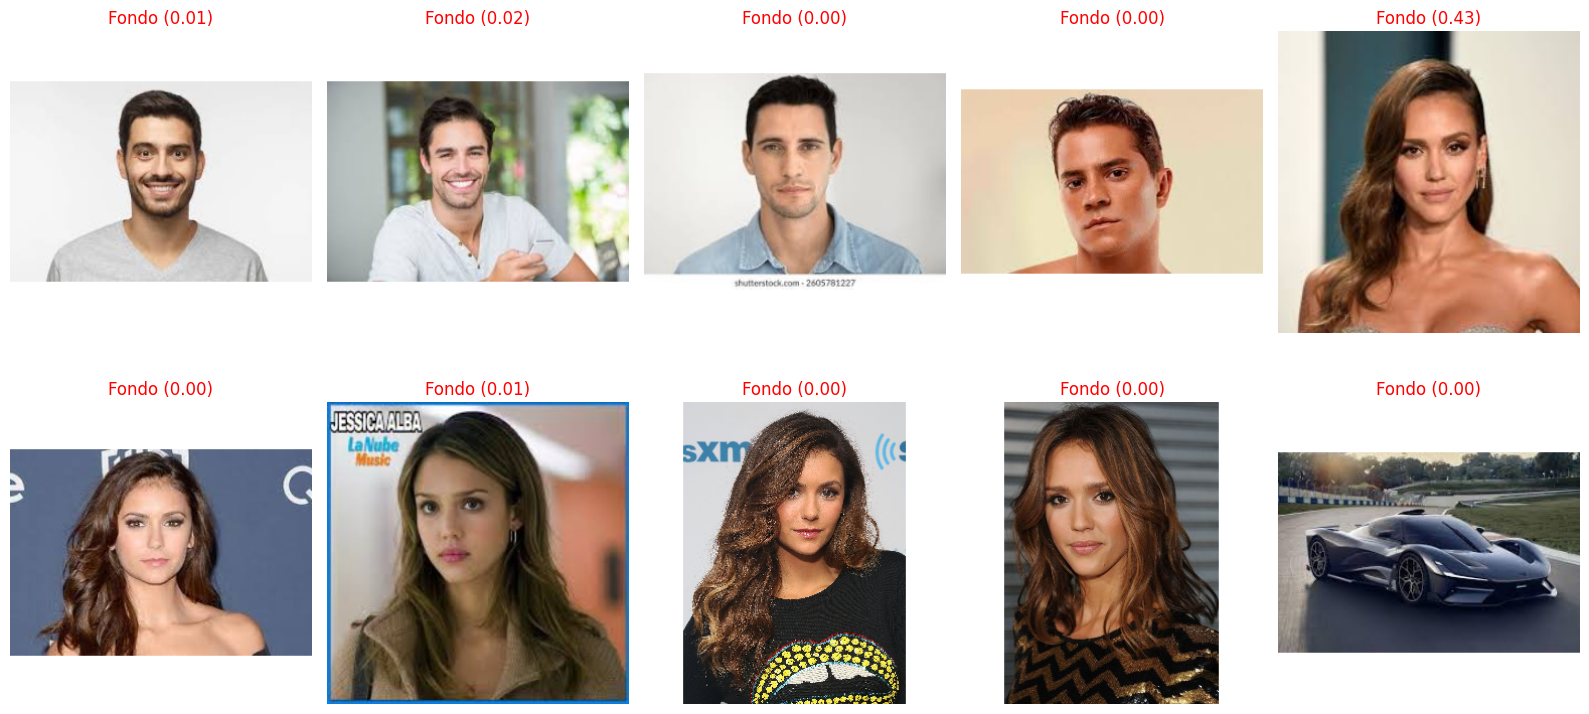

In [86]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

rutas = [
r'Bases/prueba03.jpeg',
r'Bases/prueba02.jpeg',
r'Bases/prueba01.jpeg',
r'Bases/prueba0.jpeg',
r'Bases/prueba.jpeg',
r'Bases/prueba1.jpeg',
r'Bases/prueba2.jpeg',
r'Bases/prueba3.jpg',
r'Bases/prueba4.jpg',
#r'Bases/prueba5.jpg',
r'Bases/prueba6.jpeg'
]

plt.figure(figsize=(16,8))

for i, ruta in enumerate(rutas):

    img = cv2.imread(ruta)

    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ---------- PREDICCIÓN ----------
    img_model = cv2.resize(img_rgb,(224,224))
    img_model = preprocess_input(img_model)
    img_model = np.expand_dims(img_model, axis=0)

    pred = model.predict(img_model, verbose=0)

    prob = pred[0][0]

    if prob > 0.5:
        titulo = f"Nataly ({prob:.2f})"
        color = "green"
    else:
        titulo = f"Fondo ({prob:.2f})"
        color = "red"

    # ---------- SOLO PARA VISUALIZAR ----------
    img_show = resize_con_padding(img_rgb, 300)

    plt.subplot(2,5,i+1)
    plt.imshow(img_show)
    plt.title(titulo, color=color, fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Creación de sitio con Streamlit para subir imagenes y predecir si es Nathaly o fondo.

Se crea el archivo `app.py`  que utiliza **Streamlit** para:

- Subir una imagen desde el disco 
- Preprocesar la imagen (redimensionar a 224×224, normalizar como VGG16).
- Cargar el modelo `modelo_clasificacion_rostros_fondo_op_3.h5` entrenado.
- Ejecutar la predicción y mostrar si la imagen es **Nathaly** o **Fondo**
- Mostrar la imagen de entrada y el resultado en una interfaz web interactiva.

Para ejecutarlo, instala Streamlit (`pip install streamlit`) y corre:

```bash
streamlit run app.py
```

Luego abre el navegador en http://localhost:8501 para usar la app.

### Capturas de la app en ejecución

![Interfaz Streamlit - ejemplo 1](../dataset/imagenstreamlituno.png)

![Interfaz Streamlit - ejemplo 2](../dataset/imagenstreamlitdos.png)